In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor

In [2]:
data = pd.read_csv('data/Master_Global_Budgets_Historical.csv')
data.head()

,Country,Year,Defense_Percentage,Education_Percentage,Health_Percentage,Interest_Payments_Percentage,Total_Budget_Billions_USD,Infrastructure_Percentage,Agriculture_Percentage,State_Transfers_Percentage,...,Administration_and_Others_Percentage,Defense_Amount_Billions_USD,Education_Amount_Billions_USD,Health_Amount_Billions_USD,Interest_Payments_Amount_Billions_USD,Infrastructure_Amount_Billions_USD,Agriculture_Amount_Billions_USD,State_Transfers_Amount_Billions_USD,Social_Welfare_Amount_Billions_USD,Administration_and_Others_Amount_Billions_USD
0,Argentina,1946,5.78,15.4,17.82,8.65,1.552,13.09,7.85,10.47,...,10.47,0.090,0.239,0.276,0.134,0.203,0.122,0.162,0.162,0.162
1,Argentina,1947,5.78,15.4,17.82,8.65,1.629,13.09,7.85,10.47,...,10.47,0.094,0.251,0.290,0.141,0.213,0.128,0.171,0.171,0.171
2,Argentina,1948,5.78,15.4,17.82,8.65,1.711,13.09,7.85,10.47,...,10.47,0.099,0.263,0.305,0.148,0.224,0.134,0.179,0.179,0.179
3,Argentina,1949,5.78,15.4,17.82,8.65,1.796,13.09,7.85,10.47,...,10.47,0.104,0.277,0.320,0.155,0.235,0.141,0.188,0.188,0.188
4,Argentina,1950,5.78,15.4,17.82,8.65,1.886,13.09,7.85,10.47,...,10.47,0.109,0.290,0.336,0.163,0.247,0.148,0.197,0.197,0.197


In [7]:
us_data = data[data['Country']=='USA']
us_data.head()

,Country,Year,Defense_Percentage,Education_Percentage,Health_Percentage,Interest_Payments_Percentage,Total_Budget_Billions_USD,Infrastructure_Percentage,Agriculture_Percentage,State_Transfers_Percentage,...,Administration_and_Others_Percentage,Defense_Amount_Billions_USD,Education_Amount_Billions_USD,Health_Amount_Billions_USD,Interest_Payments_Amount_Billions_USD,Infrastructure_Amount_Billions_USD,Agriculture_Amount_Billions_USD,State_Transfers_Amount_Billions_USD,Social_Welfare_Amount_Billions_USD,Administration_and_Others_Amount_Billions_USD
3401,USA,1936,9.56,13.55,16.16,6.51,49.760,8.13,5.42,10.84,...,10.84,4.757,6.742,8.041,3.239,4.045,2.697,5.394,9.444,5.394
3402,USA,1937,9.56,13.55,16.16,6.51,52.248,8.13,5.42,10.84,...,10.84,4.995,7.080,8.443,3.401,4.248,2.832,5.664,9.917,5.664
3403,USA,1938,9.56,13.55,16.16,6.51,54.860,8.13,5.42,10.84,...,10.84,5.245,7.434,8.865,3.571,4.460,2.973,5.947,10.413,5.947
3404,USA,1939,9.56,13.55,16.16,6.51,57.603,8.13,5.42,10.84,...,10.84,5.507,7.805,9.309,3.750,4.683,3.122,6.244,10.933,6.244
3405,USA,1940,9.56,13.55,16.16,6.51,60.484,8.13,5.42,10.84,...,10.84,5.782,8.196,9.774,3.937,4.917,3.278,6.556,11.480,6.556


/var/folders/9f/33mp16f51m388dc_vf66f8_r0000gn/T/ipykernel_1281/4072533998.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


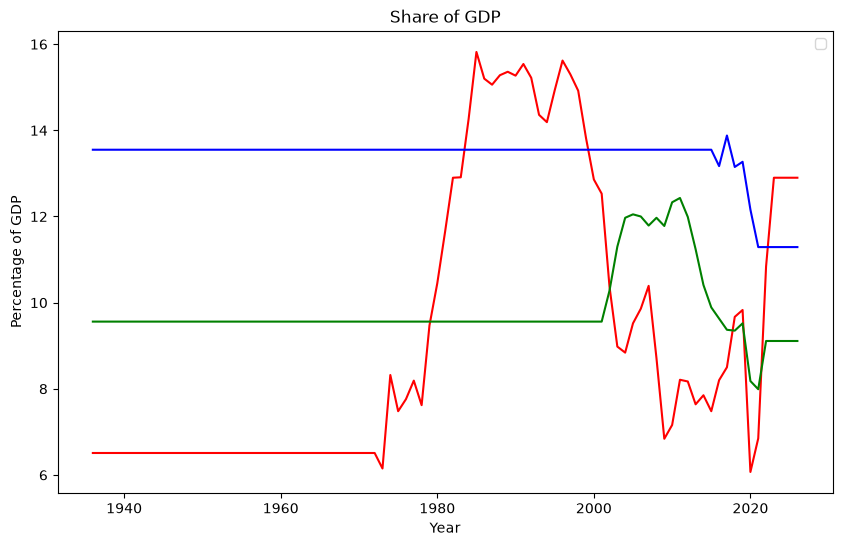

In [17]:
fig, ax = plt.subplots(1,1, figsize=(10,6))
ax.plot(us_data['Year'], us_data['Interest_Payments_Percentage'], color='red')
ax.plot(us_data['Year'], us_data['Education_Percentage'], color='blue')
ax.plot(us_data['Year'], us_data['Defense_Percentage'], color='green')
ax.set_title('Share of GDP')
ax.set_xlabel('Year')
ax.set_ylabel('Percentage of GDP')
ax.legend()
plt.show()

In [18]:
print(data['Country'].unique())

<StringArray>
[           'Argentina',            'Australia',           'Bangladesh',
               'Brazil',               'Canada',                'Chile',
                'China',             'Colombia',                'Egypt',
               'France',              'Germany',               'Greece',
                'India',            'Indonesia',                 'Iran',
              'Ireland',               'Israel',                'Italy',
                'Japan',           'Kazakhstan',             'Malaysia',
               'Mexico',          'Netherlands',          'New Zealand',
              'Nigeria',             'Pakistan',                 'Peru',
          'Philippines',               'Poland',             'Portugal',
              'Romania',               'Russia',         'Saudi Arabia',
            'Singapore',         'South Africa',          'South Korea',
                'Spain',               'Sweden',          'Switzerland',
             'Thailand',             

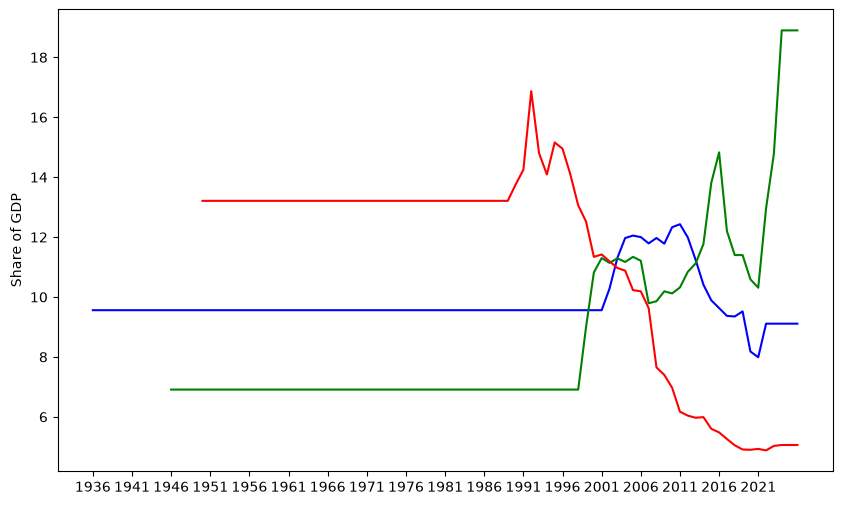

In [29]:
# Spend on defence for USA vs China vs Russia
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(data[data['Country']=='USA']['Year'], data[data['Country']=='USA']['Defense_Percentage'], color='blue')
ax.plot(data[data['Country']=='Russia']['Year'], data[data['Country']=='Russia']['Defense_Percentage'], color='green')
ax.plot(data[data['Country']=='China']['Year'], data[data['Country']=='China']['Defense_Percentage'], color='red')

ax.set_ylabel('Share of GDP')
ax.set_xticks(range(min(data['Year']), max(data['Year']),5))
plt.show()

In [30]:
print(max(data['Year']))

2026


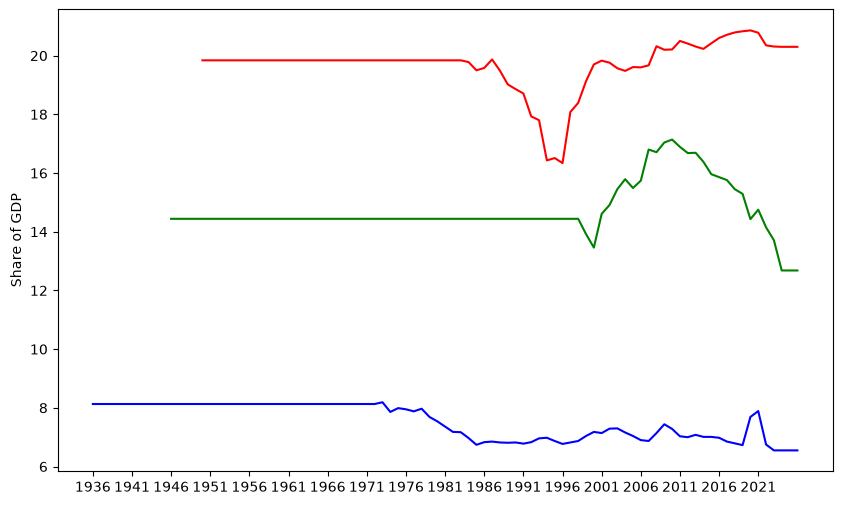

In [33]:
# Spend on infrastructure for USA vs China vs Russia
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(data[data['Country']=='USA']['Year'], data[data['Country']=='USA']['Infrastructure_Percentage'], color='blue')
ax.plot(data[data['Country']=='Russia']['Year'], data[data['Country']=='Russia']['Infrastructure_Percentage'], color='green')
ax.plot(data[data['Country']=='China']['Year'], data[data['Country']=='China']['Infrastructure_Percentage'], color='red')

ax.set_ylabel('Share of GDP')
ax.set_xticks(range(1936, 2026, 5))
plt.show()